Case 1: No solar

 Bus Voltages
      vm_pu  va_degree
0  1.000000   0.000000
1  1.000367  -0.009761
2  1.000346  -0.012735
3  1.000348  -0.012789

 Line Loadings
   loading_percent
0         1.468876
1         0.011975

 Transformer Loading
   loading_percent
0         0.094209
Case 2: Solar at full output

 Bus Voltages
      vm_pu  va_degree
0  1.000000   0.000000
1  1.006685   1.681829
2  0.998946   7.545629
3  1.012053   9.367333

 Line Loadings
   loading_percent
0        53.970528
1        86.435494

 Transformer Loading
   loading_percent
0        82.340687


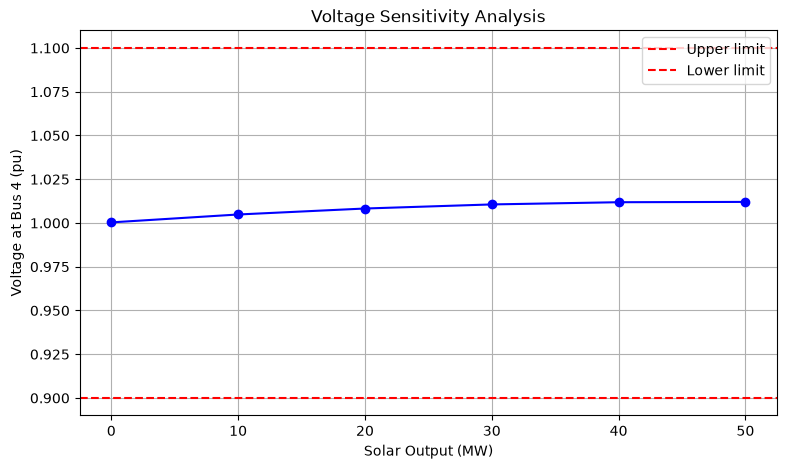

C:\Users\Allen\grid_connection_study\venv\Lib\site-packages\pandapower\build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)
C:\Users\Allen\grid_connection_study\venv\Lib\site-packages\pandapower\build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)


Fault without Solar:
     ikss_ka      skss_mw
0  10.934664  2500.000000
1   4.606876  1053.273370
2   6.311256   360.736757
3   5.172498   295.647969


C:\Users\Allen\grid_connection_study\venv\Lib\site-packages\pandapower\build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)
C:\Users\Allen\grid_connection_study\venv\Lib\site-packages\pandapower\build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)



 Fault with Solar
     ikss_ka      skss_mw
0  11.153357  2550.000000
1   4.825570  1103.273370
2   7.186030   410.736757
3   6.047271   345.647969


In [64]:
from pandapower.create import (
create_empty_network,
create_ext_grid,
create_transformer_from_parameters,
create_bus,
create_switch,
create_sgen,
create_line_from_parameters)
from pandapower.run import runpp
import matplotlib.pyplot as plt
import pandapower.plotting as plot
from pandapower.shortcircuit import calc_sc

# Building the network with the PV system connected.
net = create_empty_network()
bus1 = create_bus(net, name = "Bus 1", vn_kv = 132)
bus2 = create_bus(net, name = "Bus 2", vn_kv = 132)
bus3 = create_bus(net, name = "Bus 3", vn_kv = 33)
bus4 = create_bus(net, name = "Bus 4", vn_kv = 33)
grid = create_ext_grid(net, bus1, vm_pu = 1.0, s_sc_max_mva = 2500, s_sc_min_mva = 2000, rx_max = 0.1, rx_min = 0.1)
line1 = create_line_from_parameters(net, from_bus = bus1, to_bus = bus2, length_km = 25, r_ohm_per_km = 0.15, x_ohm_per_km = 0.4, c_nf_per_km = 10, max_i_ka = 0.4, name = "132 KV line")
trafo1 = create_transformer_from_parameters(net, hv_bus = bus2, lv_bus = bus3, sn_mva = 60, vn_hv_kv = 132, vn_lv_kv = 33, vkr_percent = 0.1, vk_percent = 12.5, pfe_kw = 50, i0_percent = 0.1, name = "Main Transformer 132/33 KV")
line2 = create_line_from_parameters(net, from_bus = bus3, to_bus = bus4, length_km = 2, r_ohm_per_km = 0.15, x_ohm_per_km = 0.35, c_nf_per_km = 10, max_i_ka = 1.0, name = "Substation connection line")
solar = create_sgen(net, bus = bus4, p_mw = 50, q_mvar = 0, sn_mva = 50, k = 1.0, name = "50 MW Solar Plant", type = "PV", scaling = 1.0)

# With no solar connection
net.sgen.p_mw = 0
runpp(net)
case_1_bus = net.res_bus.copy()
case_1_line = net.res_line.copy()
case_1_trafo = net.res_trafo.copy()
print("Case 1: No solar")
print("\n Bus Voltages")
print(case_1_bus[['vm_pu','va_degree']])
print("\n Line Loadings")
print(case_1_line[['loading_percent']])
print("\n Transformer Loading")
print(case_1_trafo[['loading_percent']])

# With Solar at full output
net.sgen.p_mw = 50
runpp(net)
case_2_bus = net.res_bus.copy()
case_2_line = net.res_line.copy()
case_2_trafo = net.res_trafo.copy()
print("Case 2: Solar at full output")
print("\n Bus Voltages")
print(case_2_bus[['vm_pu','va_degree']])
print("\n Line Loadings")
print(case_2_line[['loading_percent']])
print("\n Transformer Loading")
print(case_2_trafo[['loading_percent']])

# Sensitivity Analysis
output_levels = [0,10,20,30,40,50]
voltages = []
for p in output_levels:
    net.sgen.p_mw = p
    runpp(net)
    voltages.append(net.res_bus.vm_pu.iloc[-1])
plt.figure(figsize=(9,5))
plt.plot(output_levels, voltages, marker='o', color='blue')
plt.axhline(y=1.10, color='r', linestyle='--', label='Upper limit')
plt.axhline(y=0.90, color='r', linestyle='--', label='Lower limit')
plt.xlabel("Solar Output (MW)")
plt.ylabel("Voltage at Bus 4 (pu)")
plt.title("Voltage Sensitivity Analysis")
plt.legend()
plt.grid(True)
plt.savefig("voltage_profile.png", dpi=150)
plt.show()

# Fault Analysis
# Without Solar
net.sgen.in_service = False
calc_sc(net, fault = "3ph", case = "max")
fault_without_solar = net.res_bus_sc.copy()
print("Fault without Solar:")
print(fault_without_solar[['ikss_ka','skss_mw']])

# With Solar
net.sgen.in_service = True
calc_sc(net, fault = "3ph", case = "max")
fault_with_solar = net.res_bus_sc.copy()
print("\n Fault with Solar")
print(fault_with_solar[['ikss_ka','skss_mw']])

